# Exercise 2 — Classification Metrics

## Part A: Understanding Model Evaluation

In classification problems, accuracy alone is not always enough.

A model may appear “good” while still making important mistakes.

In this exercise, we will learn how to evaluate classification models using:

* accuracy
* precision
* recall
* F1-score
* confusion matrix

### Example Problem

Imagine we are building a spam detector.

The model predicts:

`1 = spam`

`0 = not spam`

### Step 1 — Real Labels vs Predictions

In [1]:
import numpy as np

# True labels
y_true = np.array([
    1,1,1,1,1,
    0,0,0,0,0
])

# Model predictions
y_pred = np.array([
    1,0,1,0,1,
    0,1,1,0,0
])

### Step 2 — Compute the Confusion Matrix

In [2]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)

print(cm)

[[3 2]
 [2 3]]


### Understanding the Confusion Matrix

Where:

* TP = true positives
* TN = true negatives
* FP = false positives
* FN = false negatives

### Visualize the Confusion Matrix

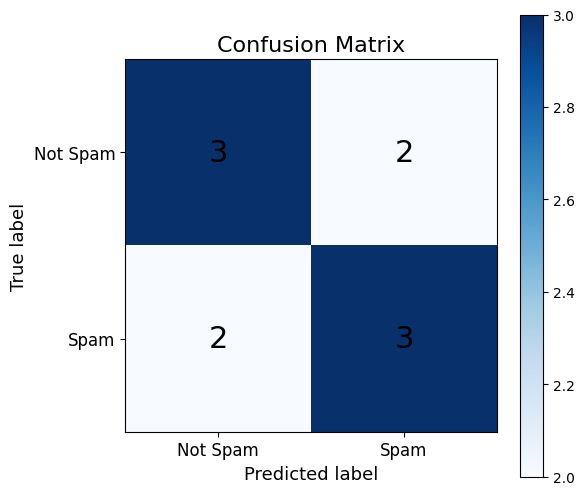

In [3]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot
plt.figure(figsize=(6,6))

plt.imshow(cm, cmap="Blues")

# Axis labels
classes = ["Not Spam", "Spam"]

plt.xticks([0,1], classes, fontsize=12)
plt.yticks([0,1], classes, fontsize=12)

# Numbers inside cells
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center",
            fontsize=22,
            color="black"
        )

# Labels
plt.xlabel("Predicted label", fontsize=13)
plt.ylabel("True label", fontsize=13)

plt.title("Confusion Matrix", fontsize=16)

plt.colorbar()

plt.show()

### Step 3 — Compute Metrics

In [4]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print(f"Accuracy : {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall   : {recall:.2f}")
print(f"F1-score : {f1:.2f}")

Accuracy : 0.60
Precision: 0.60
Recall   : 0.60
F1-score : 0.60


### What Do These Metrics Mean?

#### Accuracy
How many predictions were correct overall? There are 8 predictions correct

Precision
When the model predicts SPAM,
how often is it correct? 80% of the time

Recall
How many real spam messages
did the model find? 4 spam messages

F1-score
Balance between precision and recall


Questions

1. Is accuracy always enough?
2. What happens if classes are imbalanced?
3. Why might high accuracy still be misleading?
4. In medical diagnosis, which is worse:
    * false positive?
    * false negative?
5. Which metric would matter most for:
    * spam filtering?
    * fraud detection?
    * disease detection?

1. Is accuracy always enough?
No. Accuracy simply measures how many predictions are correct overall. However, it does not show how many errors the model makes in each category, so a model can still appear accurate while performing poorly in important cases.

2. What happens if classes are imbalanced?
Accuracy can become unreliable when one class heavily outnumbers the other. For example, if 99% of emails are spam, a model that always predicts “spam” would achieve very high accuracy despite being ineffective. The same issue occurs if almost all emails are non-spam.

3. Why might high accuracy still be misleading?
A high accuracy score does not always mean the model is good. In datasets with imbalanced classes, the model may predict the majority class most of the time while failing to correctly identify the minority class.

4. In medical diagnosis, which is worse: false positive or false negative?
A false negative is generally more serious because it means a sick patient is incorrectly classified as healthy, which could prevent them from receiving necessary treatment.

5. Which metric matters most for spam filtering?
Precision is especially important in spam filtering because we want to avoid classifying legitimate emails as spam, particularly important messages.

Which metric matters most for fraud detection?
Recall is more important for fraud detection because the goal is to identify as many fraudulent cases as possible, even if some normal cases are mistakenly flagged.

Which metric matters most for disease detection?
Recall is also crucial in disease detection since detecting as many actual cases of illness as possible is the priority.


## Part B — Try Your Own Predictions

Modify: `y_pred`

Then rerun the notebook and observe:

* how the confusion matrix changes
* how the metrics change
* which mistakes increase or decrease

## Bonus Challenge

Create:

1. a model with:
    * high precision
    * low recall
2. a model with:
    * high recall
    * low precision

Explain the difference.